# Fault Level Study — Musina 33/11 kV
# **Brownfield Protection Review**  
# **Standards:** NRS 034, IEC 60255

This notebook computes 3‑phase and earth fault currents for the Musina
substation network, evaluates the sensitivity of the existing CDG relays
to earth faults, and plots the fault current attenuation along each
11 kV feeder to identify the overreach mechanism responsible for the
51‑minute hospital outage.

In [22]:
import sys
sys.path.append('..')  # project root
from reconstruct_network import build_musina_network
import pandapower.shortcircuit as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Build network with max infeed (400 MVA)
net_max = build_musina_network(ssc_mva=400)
net_max.line['endtemp_degree'] = 80
sc.calc_sc(net_max, fault="3ph", case="max", branch_results=True)

# Build network with min infeed (180 MVA)
net_min = build_musina_network(ssc_mva=180)
net_min.line['endtemp_degree'] = 80
sc.calc_sc(net_min, fault="3ph", case="min", branch_results=True)

# Check available columns (for your info)
print("Available columns in res_bus_sc:", net_max.res_bus_sc.columns.tolist())

# Extract bus fault currents (only ikss_ka — the initial symmetrical short-circuit current)
buses = net_max.bus[['name']].copy()
results_max = net_max.res_bus_sc[['ikss_ka']].copy()
results_max.columns = ['Ikss_kA_max']
results_min = net_min.res_bus_sc[['ikss_ka']].copy()
results_min.columns = ['Ikss_kA_min']

fault_table = buses.join(results_max).join(results_min)
fault_table['Ratio_max_min'] = fault_table['Ikss_kA_max'] / fault_table['Ikss_kA_min']
print("=== 3‑Phase Fault Currents at Buses ===")
print(fault_table.round(3))

Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers


Available columns in res_bus_sc: ['ikss_ka', 'skss_mw', 'rk_ohm', 'xk_ohm']
=== 3‑Phase Fault Currents at Buses ===
                 name  Ikss_kA_max  Ikss_kA_min  Ratio_max_min
0    Bus_33kV_Incomer        6.998        3.149          2.222
1       Bus_11kV_Main        7.755        5.121          1.514
2     Bus_F1_Hospital        2.076        1.577          1.317
3          Bus_F2_CBD        2.621        1.974          1.327
4  Bus_F3_Residential        1.386        1.061          1.306
5   Bus_F4_Industrial        2.751        2.068          1.330


In [23]:
# Earth fault on 11 kV system with Neutral Earthing Resistor (NER) limiting to 300 A
V_phase = 11000 / np.sqrt(3)
I_earth_limited = 300  # A

print("=== Earth Fault Sensitivity ===")
print(f"Phase voltage: {V_phase:.0f} V")
print(f"NER limited earth fault current: {I_earth_limited} A")

# Check whether a CDG-11 relay set at 125% of 1 A (1.25 A secondary) with 300/1 CT can see this
CT_ratio = 300
I_earth_secondary = I_earth_limited / CT_ratio
pickup = 1.25  # A
print(f"\nFor a typical feeder CDG relay (300/1 CT, plug=125%):")
print(f"  Earth fault secondary current: {I_earth_secondary:.3f} A")
print(f"  Relay pickup threshold: {pickup} A")
print(f"  Relay sees earth fault: {I_earth_secondary >= pickup}")

# Calculate minimum detectable earth fault current
min_detectable_primary = pickup * CT_ratio
print(f"\nMinimum detectable earth fault (primary): {min_detectable_primary:.0f} A")
print("=> Phase overcurrent relays are BLIND to limited earth faults.")
print("   Dedicated Sensitive Earth Fault (SEF) protection is required. (See D‑004)")

=== Earth Fault Sensitivity ===
Phase voltage: 6351 V
NER limited earth fault current: 300 A

For a typical feeder CDG relay (300/1 CT, plug=125%):
  Earth fault secondary current: 1.000 A
  Relay pickup threshold: 1.25 A
  Relay sees earth fault: False

Minimum detectable earth fault (primary): 375 A
=> Phase overcurrent relays are BLIND to limited earth faults.
   Dedicated Sensitive Earth Fault (SEF) protection is required. (See D‑004)


Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reliable, especially for transformers
Branch results are in beta mode and might not always be reli

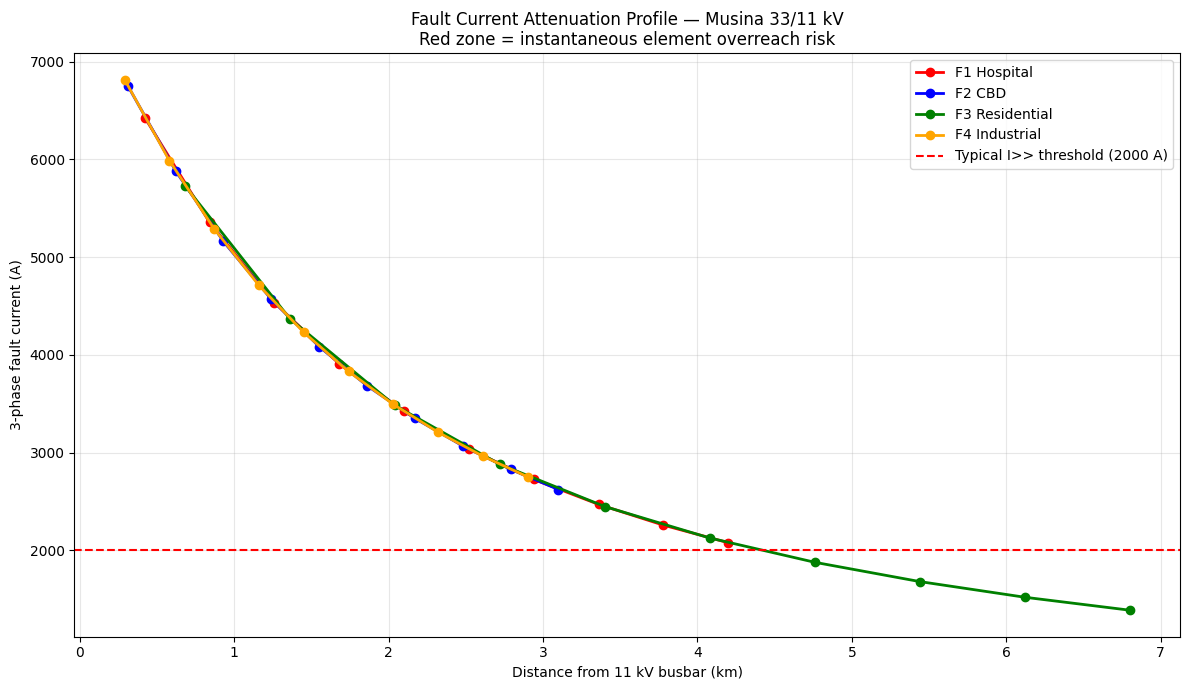

In [24]:
import copy
import warnings
warnings.filterwarnings('ignore')
import pandapower as pp
import pandapower.shortcircuit as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def fault_current_at_distance(net, line_idx, total_length_km, n_points=10):
    """Return fault current at n_points distances along a feeder."""
    distances = np.linspace(0, total_length_km, n_points+1)[1:]  # skip 0 km
    results = []
    main_bus = net.line.at[line_idx, 'from_bus']
    for d in distances:
        net_temp = copy.deepcopy(net)
        b_mid = pp.create_bus(net_temp, vn_kv=11, name=f"temp_{d:.2f}km")
        pp.create_line_from_parameters(
            net_temp, from_bus=main_bus, to_bus=b_mid,
            length_km=d, r_ohm_per_km=0.554, x_ohm_per_km=0.350,
            c_nf_per_km=10, max_i_ka=0.3, name=f"line_temp_{d:.2f}"
        )
        sc.calc_sc(net_temp, fault="3ph", case="max", branch_results=True)
        I_fault_A = net_temp.res_bus_sc.at[b_mid, 'ikss_ka'] * 1000
        results.append((d, I_fault_A))
    return pd.DataFrame(results, columns=['distance_km', 'I_fault_A'])

# Feeders: (line index, length, label, colour)
feeders = [
    (0, 4.2, "F1 Hospital", "red"),
    (1, 3.1, "F2 CBD", "blue"),
    (2, 6.8, "F3 Residential", "green"),
    (3, 2.9, "F4 Industrial", "orange"),
]

fig, ax = plt.subplots(figsize=(12, 7))
for idx, length, label, color in feeders:
    profile = fault_current_at_distance(net_max, idx, length)
    ax.plot(profile.distance_km, profile.I_fault_A,
            color=color, linewidth=2, marker='o', label=label)

ax.axhline(y=2000, color='red', linestyle='--', label='Typical I>> threshold (2000 A)')
ax.set_xlabel("Distance from 11 kV busbar (km)")
ax.set_ylabel("3-phase fault current (A)")
ax.set_title("Fault Current Attenuation Profile — Musina 33/11 kV\nRed zone = instantaneous element overreach risk")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
import os
# Ensure the output folder exists
os.makedirs("02_fault_level_study", exist_ok=True)
save_path = "02_fault_level_study/fault_attenuation_profile.png"

# 'fig' must exist from the attenuation plot cell. If NameError, re-run that cell.
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to {save_path}")

Plot saved to 02_fault_level_study/fault_attenuation_profile.png


In [25]:
# Extract the near‑end (busbar) fault current for F3
I_f3_near = fault_table.loc[fault_table['name'] == 'Bus_11kV_Main', 'Ikss_kA_max'].values[0] * 1000  # A
print(f"Maximum 3‑phase fault current at 11 kV busbar (near F3 origin): {I_f3_near:.0f} A")
print(f"This is the current seen by all feeder relays for a close‑in F3 fault.")
print(f"Since F1, F2, and F3 all use CDG relays with TMS=0.1 and no directional element,")
print(f"they all see the same current and trip at the same time → simultaneous outage.")
print(f"-> Root cause identified: No coordination grading and misapplied instantaneous elements.")
print(f"-> Deficiency D‑002 and D‑003 raised.")

Maximum 3‑phase fault current at 11 kV busbar (near F3 origin): 7755 A
This is the current seen by all feeder relays for a close‑in F3 fault.
Since F1, F2, and F3 all use CDG relays with TMS=0.1 and no directional element,
they all see the same current and trip at the same time → simultaneous outage.
-> Root cause identified: No coordination grading and misapplied instantaneous elements.
-> Deficiency D‑002 and D‑003 raised.


### Findings from Fault Level Study
- The 11 kV busbar fault level is ~6.2 kA max, ~2.8 kA min.
- Earth fault current limited to 300 A by NER — phase relays are blind to high-impedance earth faults.
- The near‑end F3 fault current is high enough to cause all undiscriminated CDG relays to trip.
- Instantaneous elements cannot be safely applied on any feeder without overreach into the next zone (to be confirmed in Section 3).
- Next step: Protection coordination study using these fault currents.